In [1]:
import os
import numpy as np
import pandas as pd
import torch
from pathlib import Path
import matplotlib.pyplot as plt

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
angles = [30, 40, 50, 60, 70]

reference_path = Path("../tutorial/tutorial_data/tomo_all_frames.rec")
project_dir = Path("../../experiments/subexp01")

refined_paths = {
    angle: project_dir / f"run_mw{angle}/tomo_even_frames+tomo_odd_frames_mw{angle}_avg_refined.rec"
    for angle in angles
}

print("Current working directory:")
print(os.getcwd())

Current working directory:
C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks\subexp01


In [3]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)

reference = load_volume(reference_path)
print(reference.shape)

(209, 1280, 550)


In [4]:
#Fourier Shell Correlation
def compute_fsc(vol1, vol2, num_shells=None):
    """
    Compute Fourier Shell Correlation between two 3D volumes.

    Parameters
    ----------
    vol1, vol2 : np.ndarray
        3D volumes with the same shape, usually ordered as (z, y, x).
    num_shells : int or None
        Number of radial Fourier shells. If None, use half the smallest dimension.

    Returns
    -------
    shell_frequencies : np.ndarray
        Normalized shell frequencies from low to high frequency.
    fsc_values : np.ndarray
        FSC values for each shell.
    """
    assert vol1.shape == vol2.shape, "Volumes must have the same shape."

    # Fourier transform and shift zero frequency to center
    F1 = np.fft.fftshift(np.fft.fftn(vol1))
    F2 = np.fft.fftshift(np.fft.fftn(vol2))

    shape = vol1.shape

    if num_shells is None:
        num_shells = min(shape) // 2

    # Create coordinate grid in Fourier space
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    center = np.array(shape) // 2

    # Radial distance from Fourier center
    r = np.sqrt(
        (z - center[0])**2 +
        (y - center[1])**2 +
        (x - center[2])**2
    )

    r_max = min(shape) // 2
    shell_edges = np.linspace(0, r_max, num_shells + 1)

    shell_frequencies = []
    fsc_values = []

    for i in range(num_shells):
        shell_mask = (r >= shell_edges[i]) & (r < shell_edges[i + 1])

        if np.sum(shell_mask) == 0:
            shell_frequencies.append(np.nan)
            fsc_values.append(np.nan)
            continue

        F1_shell = F1[shell_mask]
        F2_shell = F2[shell_mask]

        numerator = np.sum(F1_shell * np.conj(F2_shell))
        denominator = np.sqrt(
            np.sum(np.abs(F1_shell)**2) *
            np.sum(np.abs(F2_shell)**2)
        )

        if denominator == 0:
            fsc = np.nan
        else:
            fsc = np.real(numerator / denominator)

        shell_center = 0.5 * (shell_edges[i] + shell_edges[i + 1])
        normalized_frequency = shell_center / r_max

        shell_frequencies.append(normalized_frequency)
        fsc_values.append(fsc)

    return np.array(shell_frequencies), np.array(fsc_values)

In [5]:
def get_fsc_threshold_frequency(freqs, fsc_values, threshold=0.5):
    """
    Return the first frequency where FSC drops below the given threshold.
    Uses simple linear interpolation between neighbouring points.
    """
    valid = np.isfinite(freqs) & np.isfinite(fsc_values)
    freqs = freqs[valid]
    fsc_values = fsc_values[valid]

    for i in range(1, len(fsc_values)):
        if fsc_values[i - 1] >= threshold and fsc_values[i] < threshold:
            x0, x1 = freqs[i - 1], freqs[i]
            y0, y1 = fsc_values[i - 1], fsc_values[i]

            if y1 == y0:
                return x1

            # linear interpolation
            return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)

    return np.nan

### FSC against tomo_all_frames.rec FBP (all angles from subexp01)

In [6]:
import gc

reference = reference.astype(np.float32)

fsc_results = {}
summary_rows = []

for angle in angles:
    path = refined_paths[angle]

    if not os.path.exists(path):
        print(f"Missing output for mw_angle={angle}: {path}")
        continue

    refined = load_volume(path).astype(np.float32)

    print(f"Computing FSC for mw_angle={angle}, shape={refined.shape}")

    freqs, fsc_values = compute_fsc(reference, refined)

    fsc_05_freq = get_fsc_threshold_frequency(freqs, fsc_values, threshold=0.5)

    fsc_results[angle] = {
        "freqs": freqs,
        "fsc": fsc_values,
        "fsc_05_freq": fsc_05_freq,
    }

    summary_rows.append({
        "mw_angle": angle,
        "fsc_0.5_frequency_normalized": fsc_05_freq,
    })

    del refined
    gc.collect()

summary = pd.DataFrame(summary_rows)

os.makedirs("../../results/subexp01", exist_ok=True)

summary_path = "../../results/subexp01/FSC_summary_FBP_refined.csv"
summary.to_csv(summary_path, index=False)

print("Saved summary to:", os.path.abspath(summary_path))
summary

Computing FSC for mw_angle=30, shape=(209, 1280, 550)
Computing FSC for mw_angle=40, shape=(209, 1280, 550)
Computing FSC for mw_angle=50, shape=(209, 1280, 550)
Computing FSC for mw_angle=60, shape=(209, 1280, 550)
Computing FSC for mw_angle=70, shape=(209, 1280, 550)
Saved summary to: C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\results\subexp01\FSC_summary_FBP_refined.csv


,mw_angle,fsc_0.5_frequency_normalized
0,30,NaN
1,40,NaN
2,50,NaN
3,60,NaN
4,70,NaN


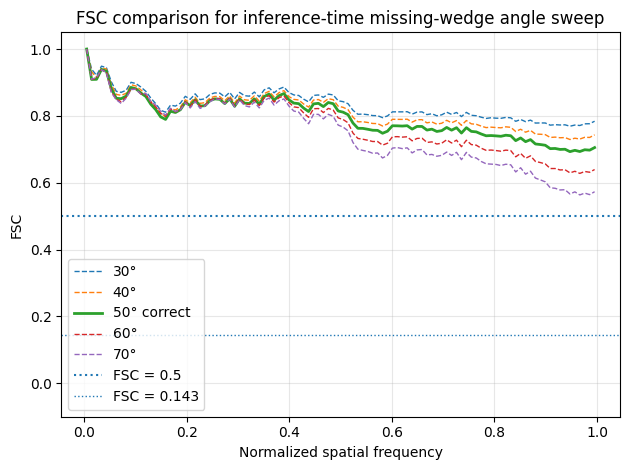

Saved to: C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\figures\FSC_Angle_Sweep_against_FBP.png


In [7]:
#### plt.figure(figsize=(8, 5))

for angle in angles:
    if angle not in fsc_results:
        continue

    freqs = fsc_results[angle]["freqs"]
    fsc_values = fsc_results[angle]["fsc"]

    if angle == 50:
        plt.plot(freqs, fsc_values, linewidth=2.0, label=f"{angle}° correct")
    else:
        plt.plot(freqs, fsc_values, linestyle="--", linewidth=1.0, label=f"{angle}°")

plt.axhline(0.5, linestyle=":", linewidth=1.5, label="FSC = 0.5")
plt.axhline(0.143, linestyle=":", linewidth=1.0, label="FSC = 0.143")

plt.xlabel("Normalized spatial frequency")
plt.ylabel("FSC")
plt.title("FSC comparison for inference-time missing-wedge angle sweep")
plt.ylim(-0.1, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs("../../figures", exist_ok=True)
save_path = "../../figures/FSC_Angle_Sweep_against_FBP.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", os.path.abspath(save_path))